# 05. Tồn kho, trả hàng, đánh giá và khách hàng

**Mục tiêu:** Hiểu các bảng vận hành phụ: kho có hay đứt hàng không, khách là ai, khách đánh giá thế nào, trả hàng vì sao, giao hàng mất bao lâu, doanh thu theo vùng/kênh và khuyến mãi.

**Bảng dữ liệu dùng:** `inventory`, `customers`, `geography`, `orders`, `order_items`, `products`, `reviews`, `returns`, `shipments`, `promotions`, `sales`

In [1]:
import sys
from pathlib import Path

# Tìm thư mục gốc repo (chứa src/ds317) để import thư viện chung
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "ds317").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ds317 import load, load_many, order_lines, revenue_daily, weekly_category, REVENUE_LABELS
from ds317.viz import setup_style, nb_out, save_fig, source_note, key_numbers, MILLION, UNIT, NOTE_SALES, NOTE_TRAFFIC

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)
setup_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
FIG, TAB = nb_out("05_ton_kho_tra_hang_khach_hang")
print("Ảnh lưu tại:", FIG.relative_to(ROOT))

Ảnh lưu tại: outputs\eda\05_ton_kho_tra_hang_khach_hang


In [2]:
import scipy.stats as st
import matplotlib.ticker as mticker

t = load_many("inventory", "customers", "geography", "orders", "order_items", "products",
              "reviews", "returns", "shipments", "promotions", "sales")
COLORS = {"Casual": "#C44E52", "GenZ": "#8172B2", "Outdoor": "#55A868", "Streetwear": "#4C72B0"}

## Kho có đáp ứng đủ đơn không, danh mục nào hay đứt hàng?

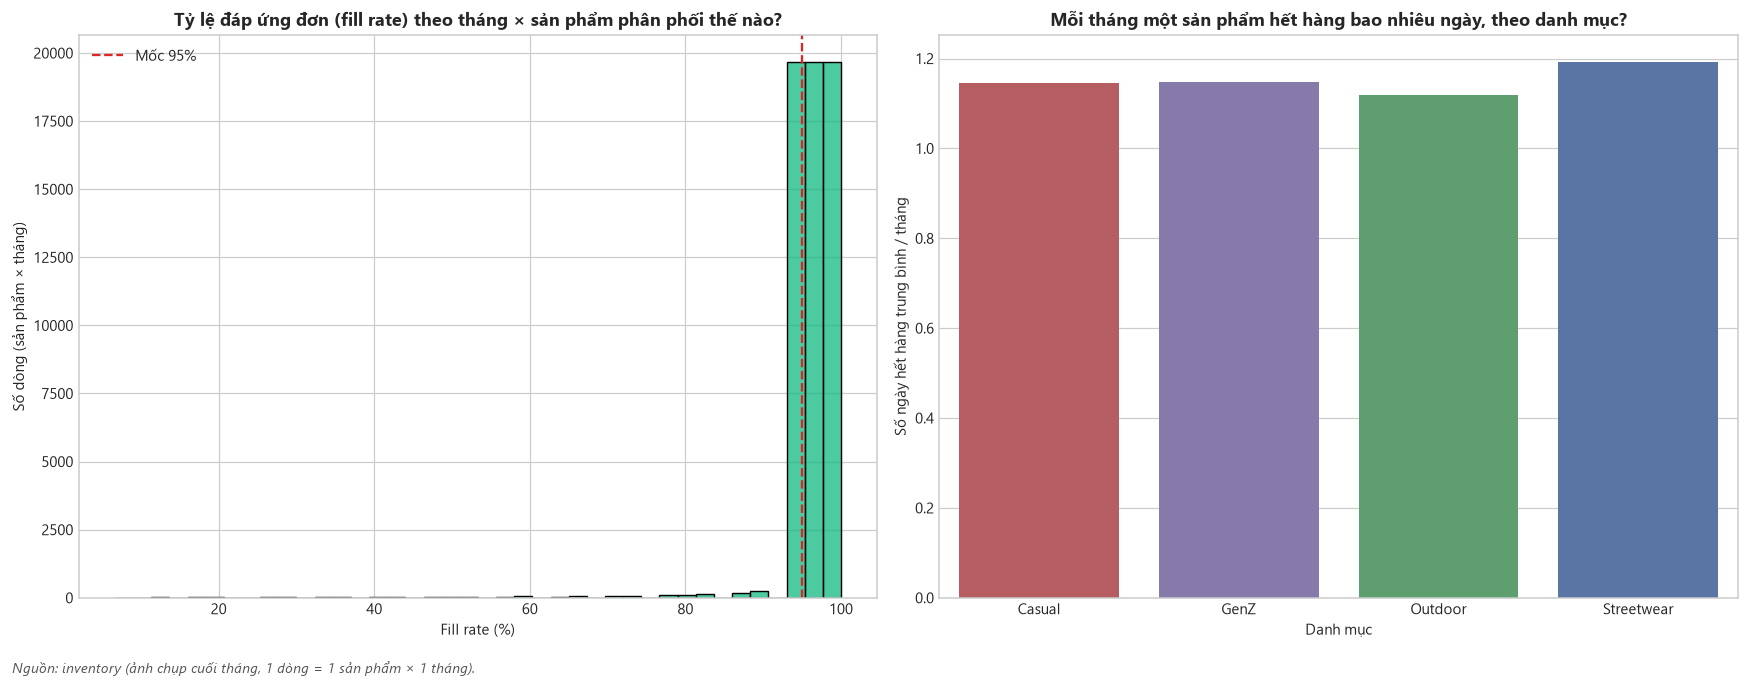

  đã lưu 05a_ton_kho_dut_hang.png


,stockout_days,stockout_flag
category,,
Casual,1.15,66.20
GenZ,1.15,68.29
Outdoor,1.12,67.35
Streetwear,1.19,67.32


In [3]:
inv = t["inventory"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(inv.fill_rate * 100, bins=40, color="#10b981", ax=axes[0])
axes[0].axvline(95, color="#dc2626", ls="--", label="Mốc 95%")
axes[0].set_title("Tỷ lệ đáp ứng đơn (fill rate) theo tháng × sản phẩm phân phối thế nào?", fontweight="bold")
axes[0].set_xlabel("Fill rate (%)")
axes[0].set_ylabel("Số dòng (sản phẩm × tháng)")
axes[0].legend()
so = inv.groupby("category").agg(stockout_days=("stockout_days", "mean"), stockout_flag=("stockout_flag", "mean"))
sns.barplot(x=so.index, y=so.stockout_days, ax=axes[1], palette=COLORS)
axes[1].set_title("Mỗi tháng một sản phẩm hết hàng bao nhiêu ngày, theo danh mục?", fontweight="bold")
axes[1].set_ylabel("Số ngày hết hàng trung bình / tháng")
axes[1].set_xlabel("Danh mục")
fig.tight_layout()
source_note(fig, "Nguồn: inventory (ảnh chụp cuối tháng, 1 dòng = 1 sản phẩm × 1 tháng).")
save_fig(fig, FIG / "05a_ton_kho_dut_hang.png")
so.assign(stockout_flag=so.stockout_flag * 100).round(2)

In [4]:
key_numbers({
    "Fill rate trung vị / % dòng < 95%": f"{inv.fill_rate.median() * 100:.1f}% / {(inv.fill_rate < 0.95).mean() * 100:.1f}%",
    "% sản phẩm × tháng có hết hàng (stockout_flag)": f"{inv.stockout_flag.mean() * 100:.1f}%",
    "Số ngày hết hàng TB / tháng": f"{inv.stockout_days.mean():.2f} (tối đa {inv.stockout_days.max()})",
    "% overstock_flag / reorder_flag": f"{inv.overstock_flag.mean() * 100:.1f}% / {inv.reorder_flag.mean() * 100:.1f}%",
})

Số liệu chính:
  - Fill rate trung vị / % dòng < 95%: 96.7% / 34.7%
  - % sản phẩm × tháng có hết hàng (stockout_flag): 67.3%
  - Số ngày hết hàng TB / tháng: 1.16 (tối đa 28)
  - % overstock_flag / reorder_flag: 76.3% / 0.0%


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Khách hàng thuộc nhóm tuổi và giới tính nào?

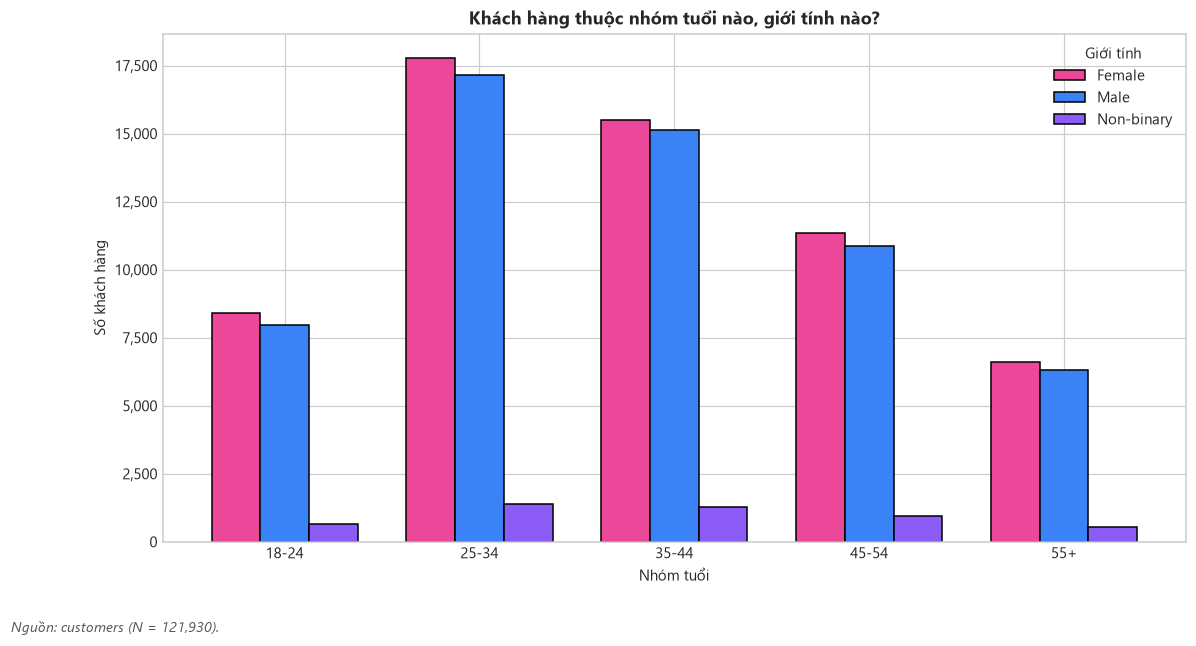

  đã lưu 05b_khach_hang_tuoi_gioi_tinh.png


In [5]:
cust = t["customers"]
ag = cust.groupby(["age_group", "gender"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 6))
ag.plot(kind="bar", ax=ax, color={"Female": "#ec4899", "Male": "#3b82f6", "Non-binary": "#8b5cf6"}, width=0.75, edgecolor="black")
ax.set_title("Khách hàng thuộc nhóm tuổi nào, giới tính nào?", fontweight="bold")
ax.set_xlabel("Nhóm tuổi")
ax.set_ylabel("Số khách hàng")
ax.tick_params(axis="x", rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.legend(title="Giới tính")
source_note(fig, f"Nguồn: customers (N = {len(cust):,}).")
save_fig(fig, FIG / "05b_khach_hang_tuoi_gioi_tinh.png")

In [6]:
age = cust.age_group.value_counts(normalize=True) * 100
key_numbers({
    "2 nhóm tuổi lớn nhất": f"{age.index[0]} ({age.iloc[0]:.1f}%), {age.index[1]} ({age.iloc[1]:.1f}%)",
    "Tỷ lệ giới tính": ", ".join(f"{k} {v:.1f}%" for k, v in (cust.gender.value_counts(normalize=True) * 100).items()),
    "Chi-square độc lập tuổi × giới: p": f"{st.chi2_contingency(ag)[1]:.3f}",
    "Số khách có ít nhất 1 đơn": f"{t['orders'].customer_id.nunique():,} / {len(cust):,}",
})

Số liệu chính:
  - 2 nhóm tuổi lớn nhất: 25-34 (29.8%), 35-44 (26.2%)
  - Tỷ lệ giới tính: Female 48.9%, Male 47.1%, Non-binary 4.0%
  - Chi-square độc lập tuổi × giới: p: 0.590
  - Số khách có ít nhất 1 đơn: 90,246 / 121,930


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Khách đánh giá sản phẩm bao nhiêu sao?

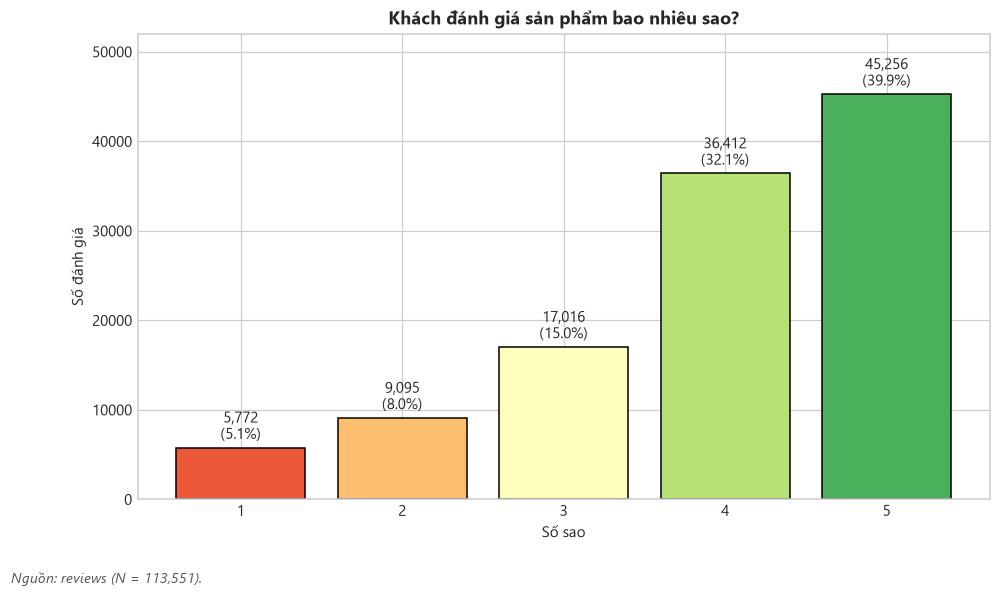

  đã lưu 05c_danh_gia_sao.png


In [7]:
rv = t["reviews"]
fig, ax = plt.subplots(figsize=(10, 5.5))
cnt = rv.rating.value_counts().sort_index()
bars = ax.bar(cnt.index.astype(str), cnt.values, color=sns.color_palette("RdYlGn", 5), edgecolor="black")
ax.bar_label(bars, labels=[f"{v:,}\n({v / cnt.sum() * 100:.1f}%)" for v in cnt.values], padding=3)
ax.margins(y=0.15)
ax.set_title("Khách đánh giá sản phẩm bao nhiêu sao?", fontweight="bold")
ax.set_xlabel("Số sao")
ax.set_ylabel("Số đánh giá")
source_note(fig, f"Nguồn: reviews (N = {len(rv):,}).")
save_fig(fig, FIG / "05c_danh_gia_sao.png")

In [8]:
key_numbers({
    "Điểm trung bình": f"{rv.rating.mean():.3f} sao",
    "% 5 sao / % 1–2 sao": f"{(rv.rating == 5).mean() * 100:.1f}% / {(rv.rating <= 2).mean() * 100:.1f}%",
    "% đơn có đánh giá": f"{rv.order_id.nunique() / len(t['orders']) * 100:.1f}%",
    "Số tiêu đề đánh giá khác nhau": f"{rv.review_title.nunique()}",
})

Số liệu chính:
  - Điểm trung bình: 3.936 sao
  - % 5 sao / % 1–2 sao: 39.9% / 13.1%
  - % đơn có đánh giá: 17.2%
  - Số tiêu đề đánh giá khác nhau: 18


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Khách trả hàng vì lý do gì?

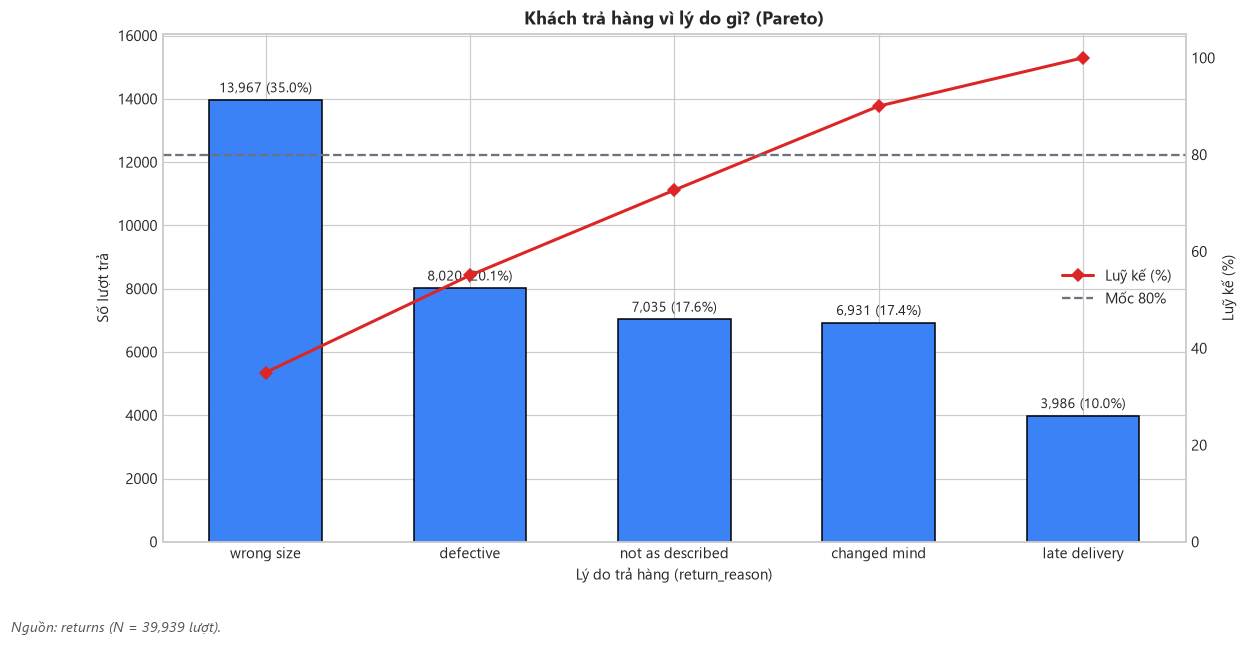

  đã lưu 05d_ly_do_tra_hang.png


In [9]:
rets = t["returns"]
rr = rets.return_reason.value_counts().rename_axis("ly_do").reset_index(name="so_luot")
rr["luy_ke_pct"] = rr.so_luot.cumsum() / rr.so_luot.sum() * 100
fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()
labels = [s.replace("_", " ") for s in rr.ly_do]
bars = ax.bar(labels, rr.so_luot, color="#3b82f6", edgecolor="black", width=0.55)
ax.bar_label(bars, labels=[f"{v:,} ({v / rr.so_luot.sum() * 100:.1f}%)" for v in rr.so_luot], padding=3, fontsize=9)
ax2.plot(labels, rr.luy_ke_pct, color="#dc2626", marker="D", lw=2, label="Luỹ kế (%)")
ax2.axhline(80, color="#6b7280", ls="--", label="Mốc 80%")
ax2.set_ylim(0, 105)
ax2.grid(False)
ax2.set_ylabel("Luỹ kế (%)")
ax2.legend(loc="center right")
ax.margins(y=0.15)
ax.set_title("Khách trả hàng vì lý do gì? (Pareto)", fontweight="bold")
ax.set_ylabel("Số lượt trả")
ax.set_xlabel("Lý do trả hàng (return_reason)")
source_note(fig, f"Nguồn: returns (N = {len(rets):,} lượt).")
save_fig(fig, FIG / "05d_ly_do_tra_hang.png")

In [10]:
key_numbers({
    "Lý do phổ biến nhất": f"{rr.ly_do[0]} ({rr.so_luot[0] / rr.so_luot.sum() * 100:.1f}%)",
    "Số lý do để đạt ≥ 80% lượt trả": f"{(rr.luy_ke_pct < 80).sum() + 1} / {len(rr)}",
    "% đơn có trả hàng": f"{rets.order_id.nunique() / len(t['orders']) * 100:.2f}%",
    "Tổng tiền hoàn": f"{rets.refund_amount.sum() / MILLION:,.1f} {UNIT}",
})

Số liệu chính:
  - Lý do phổ biến nhất: wrong_size (35.0%)
  - Số lý do để đạt ≥ 80% lượt trả: 4 / 5
  - % đơn có trả hàng: 5.57%
  - Tổng tiền hoàn: 510.6 Triệu VNĐ


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Giao hàng mất bao lâu, và giao lâu có làm khách chấm điểm thấp hơn không?

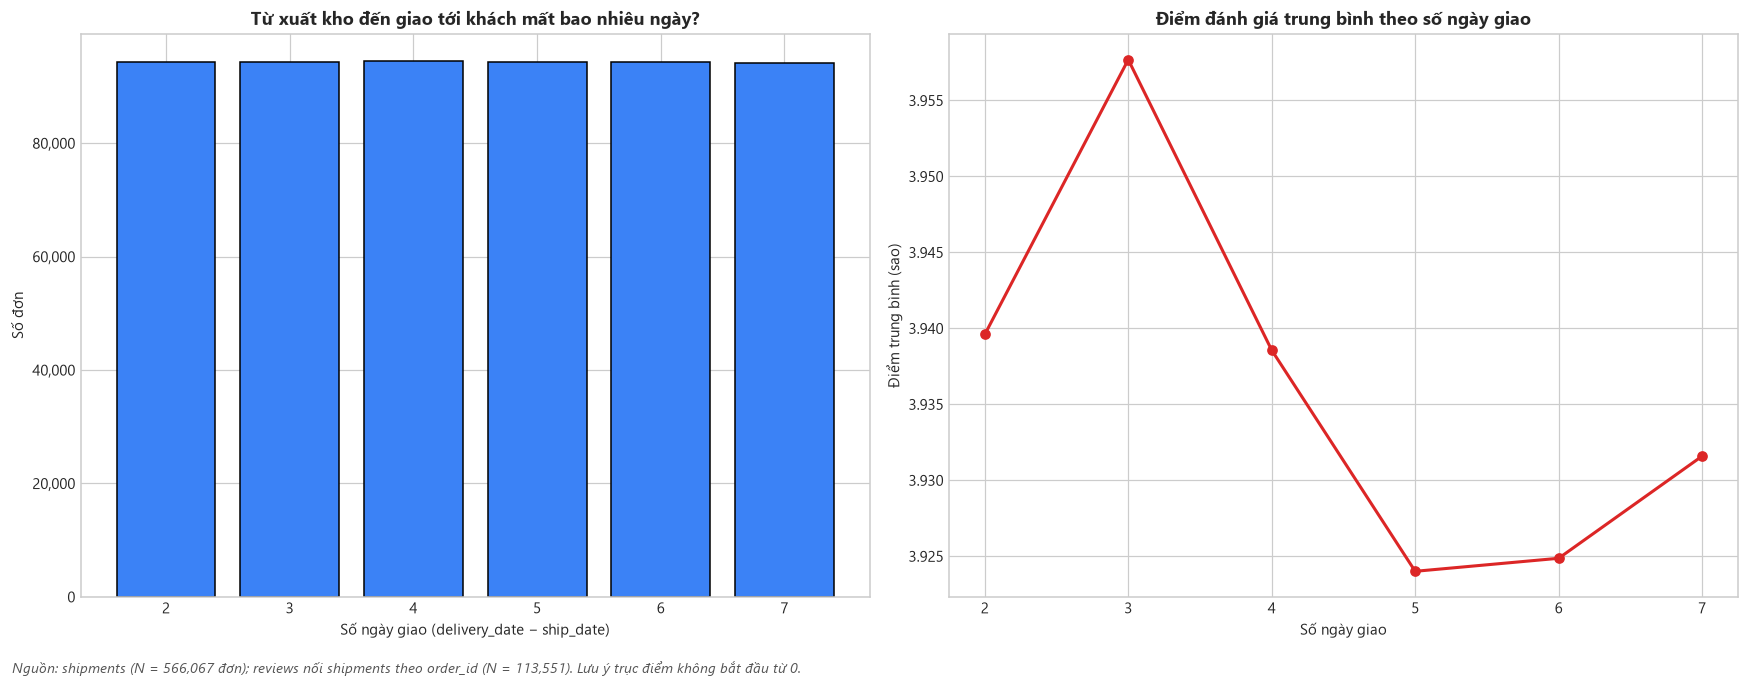

  đã lưu 05e_thoi_gian_giao.png


,diem_tb,so_danh_gia,pct_5_sao
lead_days,,,
2,3.940,18990,40.190
3,3.958,18789,40.188
4,3.939,18849,39.816
5,3.924,19016,39.814
6,3.925,19020,39.395
7,3.932,18887,39.731


In [11]:
ship = t["shipments"].assign(lead_days=lambda d: (d.delivery_date - d.ship_date).dt.days)
rs = rv.merge(ship[["order_id", "lead_days"]], on="order_id", how="inner")
agg = rs.groupby("lead_days").rating.agg(diem_tb="mean", so_danh_gia="count", pct_5_sao=lambda s: (s == 5).mean() * 100)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
lc = ship.lead_days.value_counts().sort_index()
axes[0].bar(lc.index, lc.values, color="#3b82f6", edgecolor="black")
axes[0].set_title("Từ xuất kho đến giao tới khách mất bao nhiêu ngày?", fontweight="bold")
axes[0].set_xlabel("Số ngày giao (delivery_date − ship_date)")
axes[0].set_ylabel("Số đơn")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:,.0f}"))
axes[1].plot(agg.index, agg.diem_tb, marker="o", color="#dc2626", lw=2)
axes[1].set_title("Điểm đánh giá trung bình theo số ngày giao", fontweight="bold")
axes[1].set_xlabel("Số ngày giao")
axes[1].set_ylabel("Điểm trung bình (sao)")
fig.tight_layout()
source_note(fig, f"Nguồn: shipments (N = {len(ship):,} đơn); reviews nối shipments theo order_id (N = {len(rs):,}). Lưu ý trục điểm không bắt đầu từ 0.")
save_fig(fig, FIG / "05e_thoi_gian_giao.png")
agg.round(3)

In [12]:
r = st.pearsonr(rs.lead_days, rs.rating)
f = st.f_oneway(*[g.rating for _, g in rs.groupby("lead_days")])
key_numbers({
    "Số ngày giao: min – max / trung vị": f"{ship.lead_days.min()} – {ship.lead_days.max()} / {ship.lead_days.median():.0f} ngày",
    "Pearson r (số ngày giao, số sao)": f"{r.statistic:.4f} (p = {r.pvalue:.4f})",
    "ANOVA một chiều theo số ngày giao": f"F = {f.statistic:.3f} (p = {f.pvalue:.4f})",
    "Chênh điểm TB cao nhất − thấp nhất": f"{agg.diem_tb.max() - agg.diem_tb.min():.3f} sao",
})

Số liệu chính:
  - Số ngày giao: min – max / trung vị: 2 – 7 / 4 ngày
  - Pearson r (số ngày giao, số sao): -0.0065 (p = 0.0289)
  - ANOVA một chiều theo số ngày giao: F = 2.218 (p = 0.0496)
  - Chênh điểm TB cao nhất − thấp nhất: 0.034 sao


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Doanh thu đến từ vùng nào, kênh thu hút nào, giá trị đơn mỗi vùng ra sao?

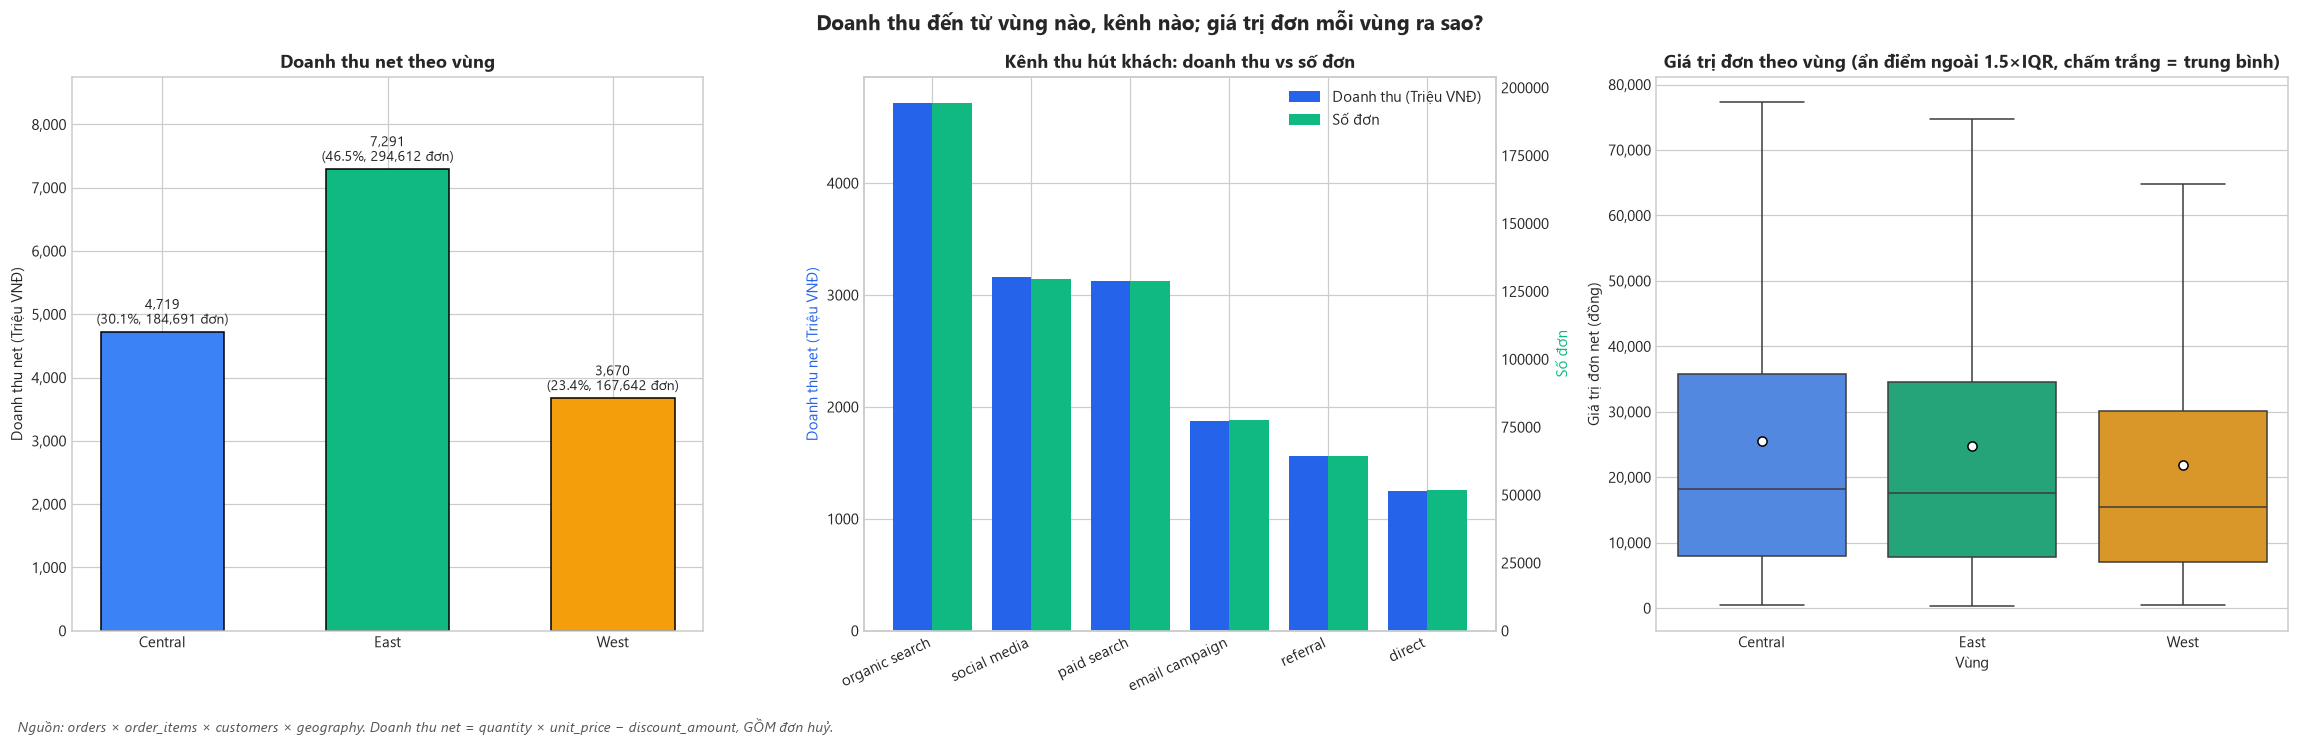

  đã lưu 05f_khach_hang_vung_kenh.png


,count,mean,std,min,25%,50%,75%,max,IQR
region,,,,,,,,,
Central,184691.0,25553.0,23446.0,434.0,8003.0,18180.0,35726.0,246463.0,27722.0
East,294612.0,24748.0,22625.0,390.0,7879.0,17641.0,34607.0,271912.0,26728.0
West,167642.0,21893.0,20484.0,429.0,7058.0,15486.0,30132.0,331570.0,23075.0


In [13]:
oi = t["order_items"].assign(item_revenue=lambda d: d.quantity * d.unit_price - d.discount_amount)
geo = t["geography"].drop_duplicates("zip")[["zip", "region"]]
orders_full = (t["orders"].merge(oi.groupby("order_id").item_revenue.sum().reset_index(), on="order_id", how="left")
               .merge(cust[["customer_id", "acquisition_channel"]], on="customer_id", how="left")
               .merge(geo, on="zip", how="left"))
REG = {"Central": "#3b82f6", "East": "#10b981", "West": "#f59e0b"}

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
reg = orders_full.groupby("region").item_revenue.agg(["sum", "count"])
bars = axes[0].bar(reg.index, reg["sum"] / MILLION, color=[REG[r] for r in reg.index], edgecolor="black", width=0.55)
axes[0].bar_label(bars, labels=[f"{s / MILLION:,.0f}\n({s / reg['sum'].sum() * 100:.1f}%, {c:,} đơn)" for s, c in zip(reg["sum"], reg["count"])], padding=3, fontsize=9)
axes[0].margins(y=0.2)
axes[0].set_title("Doanh thu net theo vùng", fontweight="bold")
axes[0].set_ylabel(f"Doanh thu net ({UNIT})")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:,.0f}"))

ch = orders_full.groupby("acquisition_channel").agg(so_don=("order_id", "count"), doanh_thu=("item_revenue", "sum")).sort_values("doanh_thu", ascending=False)
x = np.arange(len(ch))
axes[1].bar(x - 0.2, ch.doanh_thu / MILLION, 0.4, color="#2563eb", label=f"Doanh thu ({UNIT})")
ax2 = axes[1].twinx()
ax2.bar(x + 0.2, ch.so_don, 0.4, color="#10b981", label="Số đơn")
ax2.grid(False)
axes[1].set_xticks(x, [c.replace("_", " ") for c in ch.index], rotation=25, ha="right")
axes[1].set_title("Kênh thu hút khách: doanh thu vs số đơn", fontweight="bold")
axes[1].set_ylabel(f"Doanh thu net ({UNIT})", color="#2563eb")
ax2.set_ylabel("Số đơn", color="#10b981")
h1, l1 = axes[1].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper right")

sns.boxplot(data=orders_full, x="region", y="item_revenue", ax=axes[2], palette=REG, showfliers=False, showmeans=True,
            order=list(REG), meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"})
axes[2].set_title("Giá trị đơn theo vùng (ẩn điểm ngoài 1.5×IQR, chấm trắng = trung bình)", fontweight="bold")
axes[2].set_xlabel("Vùng")
axes[2].set_ylabel("Giá trị đơn net (đồng)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:,.0f}"))
fig.suptitle("Doanh thu đến từ vùng nào, kênh nào; giá trị đơn mỗi vùng ra sao?", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, "Nguồn: orders × order_items × customers × geography. Doanh thu net = quantity × unit_price − discount_amount, GỒM đơn huỷ.")
save_fig(fig, FIG / "05f_khach_hang_vung_kenh.png")
q = orders_full.groupby("region").item_revenue.describe()
q.assign(IQR=q["75%"] - q["25%"]).round(0)

In [14]:
kw = st.kruskal(*[g.item_revenue.dropna() for _, g in orders_full.groupby("region")])
key_numbers({
    "Vùng doanh thu lớn nhất": f"{reg['sum'].idxmax()} ({reg['sum'].max() / reg['sum'].sum() * 100:.1f}%)",
    "Kênh doanh thu lớn nhất": f"{ch.index[0]} ({ch.doanh_thu.iloc[0] / ch.doanh_thu.sum() * 100:.1f}%)",
    "Trung vị giá trị đơn theo vùng": ", ".join(f"{r} {v:,.0f}" for r, v in q["50%"].items()),
    "Kruskal-Wallis giữa 3 vùng": f"H = {kw.statistic:,.1f}, p = {kw.pvalue:.1e}",
})

Số liệu chính:
  - Vùng doanh thu lớn nhất: East (46.5%)
  - Kênh doanh thu lớn nhất: organic_search (30.1%)
  - Trung vị giá trị đơn theo vùng: Central 18,180, East 17,641, West 15,486
  - Kruskal-Wallis giữa 3 vùng: H = 2,165.7, p = 0.0e+00


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Danh mục nào bị trả nhiều, và doanh thu thay đổi thế nào khi có khuyến mãi?

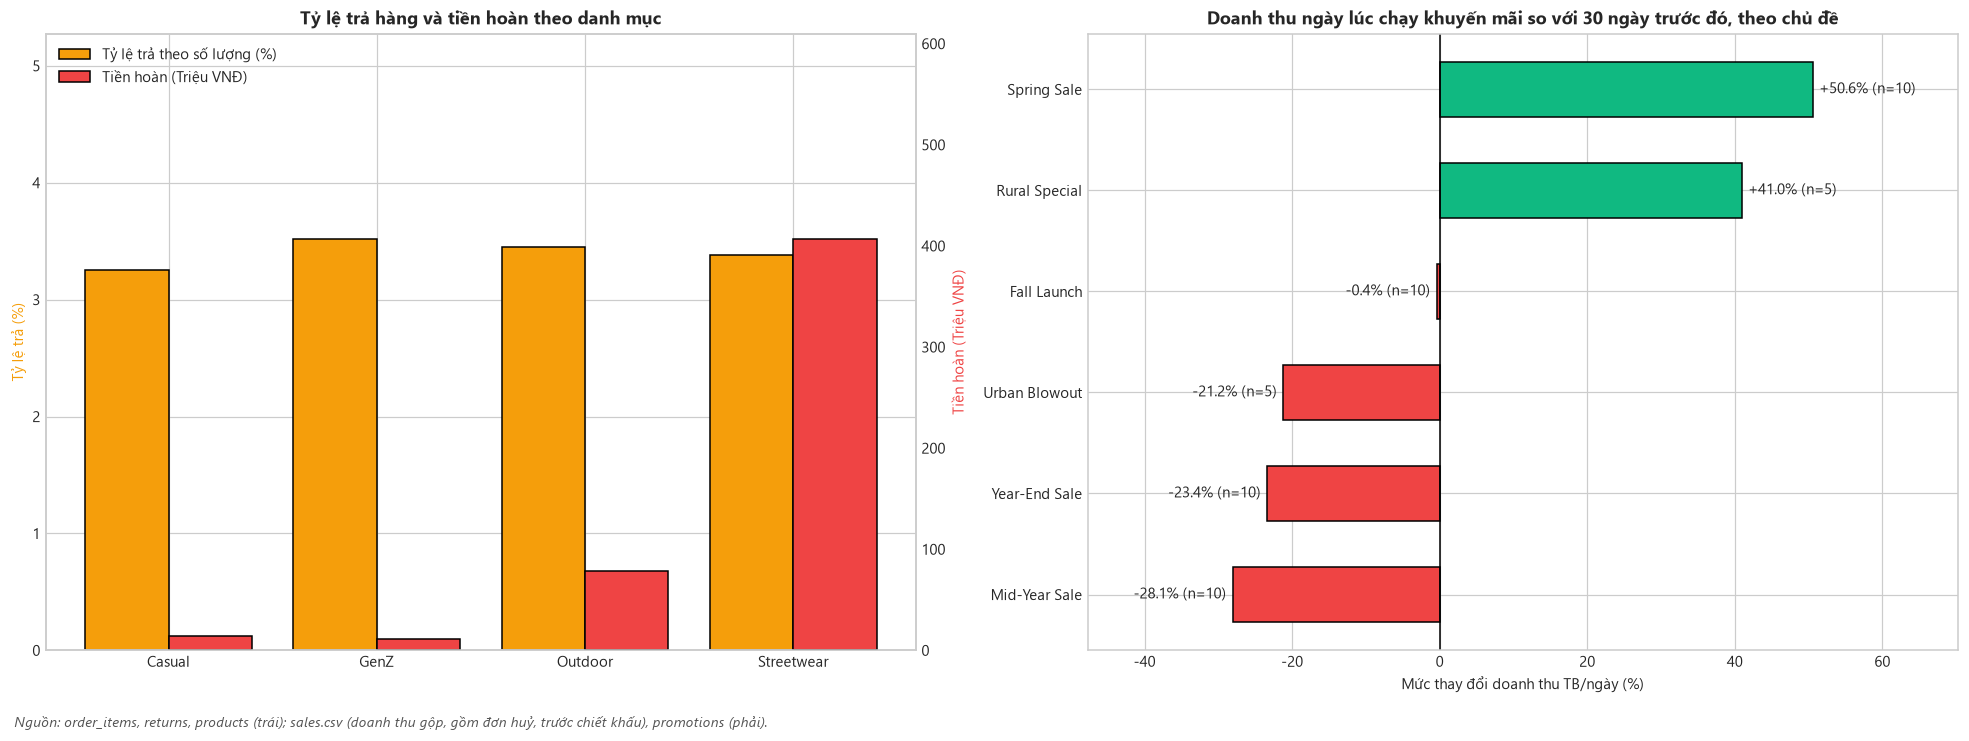

  đã lưu 05g_van_hanh_tra_hang_khuyen_mai.png


,sl_ban,sl_tra,ty_le_tra_pct,tien_hoan_trieu
category,,,,
Casual,107469,3499,3.26,14.03
GenZ,166848,5869,3.52,11.15
Outdoor,1170000,40417,3.45,78.72
Streetwear,1768826,59801,3.38,406.71


In [15]:
prod = t["products"][["product_id", "category"]]
cat = oi.merge(prod, on="product_id").groupby("category").quantity.sum().rename("sl_ban").to_frame()
cat = cat.join(rets.merge(prod, on="product_id").groupby("category").agg(sl_tra=("return_quantity", "sum"), tien_hoan=("refund_amount", "sum")))
cat["ty_le_tra_pct"] = cat.sl_tra / cat.sl_ban * 100

si = t["sales"].set_index("Date").sort_index()
promos = t["promotions"].assign(theme=lambda d: d.promo_name.str.replace(r"\s\d{4}$", "", regex=True))
lifts = []
for r in promos.itertuples():
    before = si.loc[r.start_date - pd.Timedelta(days=30):r.start_date - pd.Timedelta(days=1), "Revenue"]
    during = si.loc[r.start_date:r.end_date, "Revenue"]
    if len(before) and len(during):
        lifts.append({"promo_name": r.promo_name, "theme": r.theme, "lift_pct": (during.mean() / before.mean() - 1) * 100})
lf = pd.DataFrame(lifts)
th = lf.groupby("theme").lift_pct.agg(["mean", "count"]).sort_values("mean")

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
x = np.arange(len(cat))
axes[0].bar(x - 0.2, cat.ty_le_tra_pct, 0.4, color="#f59e0b", edgecolor="black", label="Tỷ lệ trả theo số lượng (%)")
ax2 = axes[0].twinx()
ax2.bar(x + 0.2, cat.tien_hoan / MILLION, 0.4, color="#ef4444", edgecolor="black", label=f"Tiền hoàn ({UNIT})")
ax2.grid(False)
axes[0].set_xticks(x, cat.index)
axes[0].set_ylim(0, cat.ty_le_tra_pct.max() * 1.5)
ax2.set_ylim(0, cat.tien_hoan.max() / MILLION * 1.5)
axes[0].set_ylabel("Tỷ lệ trả (%)", color="#f59e0b")
ax2.set_ylabel(f"Tiền hoàn ({UNIT})", color="#ef4444")
axes[0].set_title("Tỷ lệ trả hàng và tiền hoàn theo danh mục", fontweight="bold")
h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, loc="upper left")
bars = axes[1].barh(th.index, th["mean"], color=["#10b981" if v > 0 else "#ef4444" for v in th["mean"]], edgecolor="black", height=0.55)
axes[1].bar_label(bars, labels=[f"{v:+.1f}% (n={n})" for v, n in zip(th["mean"], th["count"])], padding=4)
axes[1].axvline(0, color="black", lw=1)
axes[1].margins(x=0.25)
axes[1].set_title("Doanh thu ngày lúc chạy khuyến mãi so với 30 ngày trước đó, theo chủ đề", fontweight="bold")
axes[1].set_xlabel("Mức thay đổi doanh thu TB/ngày (%)")
fig.tight_layout()
source_note(fig, "Nguồn: order_items, returns, products (trái); sales.csv (doanh thu gộp, gồm đơn huỷ, trước chiết khấu), promotions (phải).")
save_fig(fig, FIG / "05g_van_hanh_tra_hang_khuyen_mai.png")
lf.to_csv(TAB / "lift_khuyen_mai.csv", index=False, encoding="utf-8-sig")
cat.assign(tien_hoan_trieu=cat.tien_hoan / MILLION).drop(columns="tien_hoan").round(2)

In [16]:
disc = oi[oi.discount_amount > 0]
key_numbers({
    "Tỷ lệ trả theo danh mục": ", ".join(f"{c} {v:.2f}%" for c, v in cat.ty_le_tra_pct.items()),
    "Danh mục tiền hoàn lớn nhất": f"{cat.tien_hoan.idxmax()} ({cat.tien_hoan.max() / MILLION:,.1f} {UNIT})",
    "Mức thay đổi theo chủ đề khuyến mãi": ", ".join(f"{k} {v:+.1f}%" for k, v in th["mean"].sort_values(ascending=False).items()),
    "% dòng hàng có promo_id / mức chiết khấu TB dòng có giảm giá": f"{oi.promo_id.notna().mean() * 100:.1f}% / {(disc.discount_amount / (disc.quantity * disc.unit_price)).mean() * 100:.1f}%",
})

Số liệu chính:
  - Tỷ lệ trả theo danh mục: Casual 3.26%, GenZ 3.52%, Outdoor 3.45%, Streetwear 3.38%
  - Danh mục tiền hoàn lớn nhất: Streetwear (406.7 Triệu VNĐ)
  - Mức thay đổi theo chủ đề khuyến mãi: Spring Sale +50.6%, Rural Special +41.0%, Fall Launch -0.4%, Urban Blowout -21.2%, Year-End Sale -23.4%, Mid-Year Sale -28.1%
  - % dòng hàng có promo_id / mức chiết khấu TB dòng có giảm giá: 38.7% / 14.3%


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Vấn đề phương pháp cần nhóm quyết

- **Doanh thu theo vùng/kênh (05f) đang gồm đơn huỷ** (`order_status = cancelled`). Có nên lọc theo `order_status` không? Nếu lọc, tỷ trọng các vùng thay đổi bao nhiêu?
- **Mức thay đổi doanh thu khi khuyến mãi (05g)** đang so với 30 ngày ngay trước đó → lẫn hiệu ứng mùa vụ (ví dụ đợt đầu mùa cao điểm sẽ trông như "tăng mạnh"). Có nên so với cùng kỳ năm trước, hoặc dùng phần dư sau STL (notebook 01)?
- Một chủ đề khuyến mãi chỉ có 5–10 đợt → mức thay đổi trung bình dao động lớn; cần xem từng đợt trong `tables/lift_khuyen_mai.csv`.